# EdNet 전처리

`02_build_tables`에서 만든 테이블에 연결만 해서 분석합니다. 재시작해도 테이블을 다시 만들지 않습니다.

## 0. DB 연결
`read_only=True`: 분석 중 실수로 테이블을 덮어쓰지 않도록 읽기 전용으로 엽니다.

In [29]:
import duckdb

con = duckdb.connect("../data/ednet.duckdb", read_only=True)

### 데이터 미리보기
KT1은 유저가 문제를 푼 기록이 한 행씩 쌓인 테이블이고, 컬럼은 6개입니다.

In [30]:
con.sql("SELECT * FROM kt1 LIMIT 10").df()

,user_id,timestamp,solving_id,question_id,user_answer,elapsed_time
0,u1,1565096190868,1,q5012,b,38000
1,u1,1565096221062,2,q4706,c,24000
2,u1,1565096293432,3,q4366,b,68000
3,u1,1565096339668,4,q4829,a,42000
4,u1,1565096401774,5,q6528,b,59000
5,u1,1565096463370,6,q4793,a,58000
6,u1,1565096501746,7,q6488,a,35000
7,u1,1565097101361,8,q356,b,23000
8,u1,1565097171393,9,q1382,c,22000
9,u1,1565097240758,10,q830,b,25000


## 1. `user_id` 검증

### 1-1. 결측치·형식 확인
빈 값이 없는지, 모두 `u숫자` 형식인지 확인합니다 → 이상 없음, 유저 784,309명

In [31]:
con.sql("""
SELECT
    COUNT(*) FILTER (WHERE user_id IS NULL) AS null_count,
    COUNT(*) FILTER (WHERE NOT regexp_matches(user_id, '^u[0-9]+$')) AS bad_format_count,
    COUNT(DISTINCT user_id) AS user_count
FROM kt1
""").df()

,null_count,bad_format_count,user_count
0,0,0,784309


### 1-2. 중복 행 확인
유저·시각·문제가 같은 행을 중복으로 봅니다 → 중복 3,452건 (유저 803명). 모두 6개 컬럼이 완전히 같은 행입니다.

| 쿼리 행 | 설명 |
|---|---|
| `WITH dup AS (...)` | 중복 묶음만 모은 임시 테이블 `dup`을 만듦 |
| `GROUP BY user_id, timestamp, question_id` | 유저·시각·문제가 같은 행끼리 하나로 묶음 |
| `HAVING COUNT(*) > 1` | 행이 2개 이상인 묶음 = 중복만 남김 |
| `COUNT(*) AS dup_group_count` | 중복 묶음 수 |
| `COUNT(DISTINCT user_id) AS dup_user_count` | 중복이 있는 유저 수 |

In [32]:
con.sql("""
WITH dup AS (
    SELECT
        user_id,
        timestamp,
        question_id
    FROM kt1
    GROUP BY user_id, timestamp, question_id
    HAVING COUNT(*) > 1
)
SELECT
    COUNT(*) AS dup_group_count,
    COUNT(DISTINCT user_id) AS dup_user_count
FROM dup
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,dup_group_count,dup_user_count
0,3452,803


#### 중복 행 예시
반복 횟수가 많은 중복 10건을 봅니다 → 같은 행이 최대 36번 반복되며, 상위 사례가 모두 2019-09-18의 짧은 시간대에 몰려 있습니다.

| 쿼리 행 | 설명 |
|---|---|
| `SELECT user_id, ..., elapsed_time` | 6개 컬럼을 모두 보여줌 |
| `COUNT(*) AS dup_count` | 같은 행이 몇 번 반복됐는지 셈 |
| `GROUP BY user_id, ..., elapsed_time` | 6개 컬럼이 모두 같은 행끼리 하나로 묶음 |
| `HAVING COUNT(*) > 1` | 2번 이상 반복된 묶음 = 중복만 남김 |
| `ORDER BY dup_count DESC, user_id, timestamp` | 많이 반복된 순으로 정렬 (같으면 유저·시각 순) |
| `LIMIT 10` | 상위 10건만 보여줌 |

In [33]:
con.sql("""
SELECT
    user_id,
    timestamp,
    solving_id,
    question_id,
    user_answer,
    elapsed_time,
    COUNT(*) AS dup_count
FROM kt1
GROUP BY user_id, timestamp, solving_id, question_id, user_answer, elapsed_time
HAVING COUNT(*) > 1
ORDER BY dup_count DESC, user_id, timestamp
LIMIT 10
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,timestamp,solving_id,question_id,user_answer,elapsed_time,dup_count
0,u373,1568776999733,24490,q2390,c,28333,36
1,u373,1568776999730,24490,q2389,a,28333,35
2,u373,1568776999709,24490,q2388,c,28333,34
3,u373,1568776863500,24489,q1941,c,18000,30
4,u31604,1568774514518,78,q3911,d,10000,29
5,u373,1568776863483,24489,q1942,a,18000,29
6,u373,1568776863474,24489,q1943,d,18000,28
7,u31604,1568774497217,77,q5328,b,11000,27
8,u6184,1568775300840,482,q2907,d,26333,27
9,u6184,1568775300850,482,q2909,a,26333,26


#### 값이 살짝 다른 중복 확인
유저·`solving_id`·문제가 같은데 `timestamp`가 다르거나 `elapsed_time`이 다른 묶음을 셉니다 → `timestamp`가 다른 묶음 675,805건, `elapsed_time`이 다른 묶음 616,339건

| 쿼리 행 | 설명 |
|---|---|
| `GROUP BY user_id, solving_id, question_id` | 유저·`solving_id`·문제가 같은 행끼리 하나로 묶음 |
| `COUNT(DISTINCT timestamp) AS ts_kinds` | 묶음 안의 `timestamp` 값 종류 수 |
| `COUNT(DISTINCT elapsed_time) AS et_kinds` | 묶음 안의 `elapsed_time` 값 종류 수 |
| `COUNT(*) FILTER (WHERE ts_kinds > 1)` | `timestamp`가 2가지 이상인 묶음 수 = `timestamp`가 다른 경우 |
| `COUNT(*) FILTER (WHERE et_kinds > 1)` | `elapsed_time`이 2가지 이상인 묶음 수 = `elapsed_time`이 다른 경우 |

In [34]:
con.sql("""
WITH grp AS (
    SELECT
        user_id,
        solving_id,
        question_id,
        COUNT(DISTINCT timestamp) AS ts_kinds,
        COUNT(DISTINCT elapsed_time) AS et_kinds
    FROM kt1
    GROUP BY user_id, solving_id, question_id
)
SELECT
    COUNT(*) FILTER (WHERE ts_kinds > 1) AS ts_diff_groups,
    COUNT(*) FILTER (WHERE et_kinds > 1) AS et_diff_groups
FROM grp
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,ts_diff_groups,et_diff_groups
0,675805,616339


### 1-3. 유저별 푼 문제 수 분포
중앙값은 10문제지만 평균은 약 102문제, 최대 11,466문제로 **소수의 헤비 유저에 크게 치우친 분포**입니다.

In [35]:
summary = con.sql("""
WITH per_user AS (
    SELECT
        user_id,
        COUNT(DISTINCT question_id) AS solved_count
    FROM kt1
    GROUP BY user_id
)
SELECT
    MIN(solved_count) AS min_solved,
    quantile_cont(solved_count, 0.25) AS q1,
    median(solved_count) AS median_solved,
    quantile_cont(solved_count, 0.75) AS q3,
    MAX(solved_count) AS max_solved,
    AVG(solved_count) AS avg_solved
FROM per_user
""").df()

summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_solved,q1,median_solved,q3,max_solved,avg_solved
0,1,7.0,10.0,37.0,11466,101.911324


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

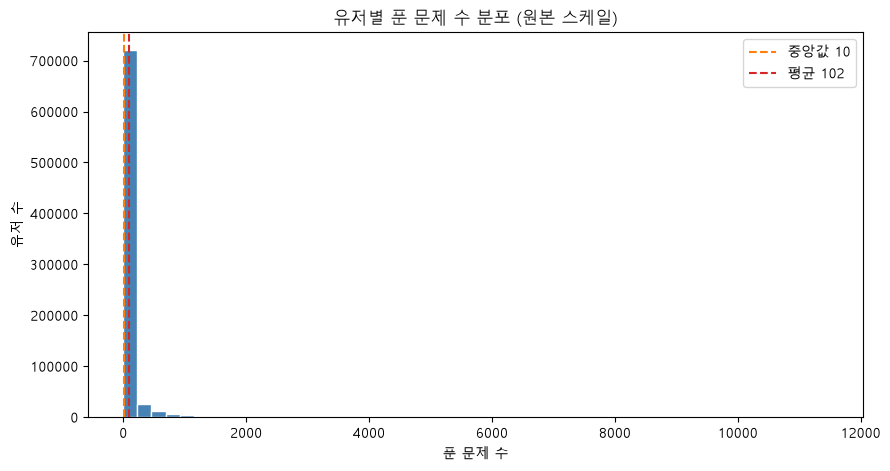

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 깨짐 방지 (Windows 기본 한글 폰트)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

per_user = con.sql("""
SELECT
    user_id,
    COUNT(DISTINCT question_id) AS solved_count
FROM kt1
GROUP BY user_id
""").df()

# 로그 변환 없이 원래 값 그대로 그린 히스토그램
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(per_user["solved_count"], bins=50, color="steelblue", edgecolor="white")
ax.axvline(summary["median_solved"][0], color="tab:orange", linestyle="--", label=f"중앙값 {summary['median_solved'][0]:.0f}")
ax.axvline(summary["avg_solved"][0], color="tab:red", linestyle="--", label=f"평균 {summary['avg_solved'][0]:.0f}")
ax.set_xlabel("푼 문제 수")
ax.set_ylabel("유저 수")
ax.set_title("유저별 푼 문제 수 분포 (원본 스케일)")
ax.legend()
plt.show()

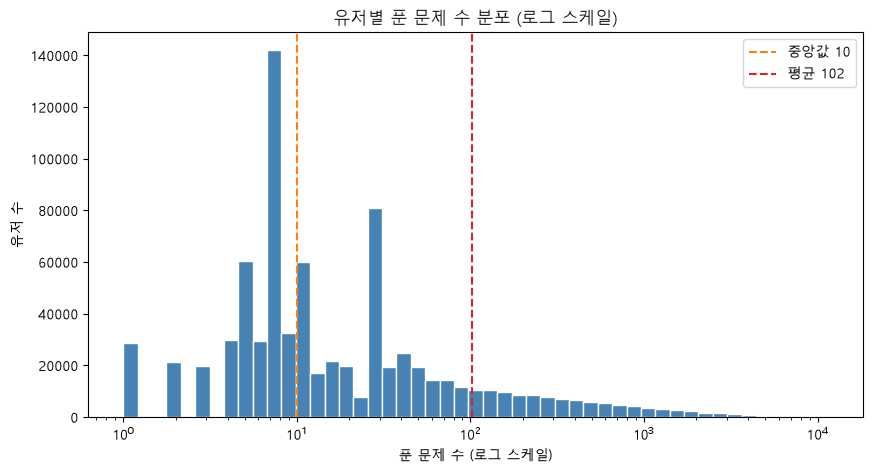

In [37]:
# 꼬리가 긴 분포라 구간을 로그 간격으로 나누고 x축도 로그 스케일로 표시
bins = np.logspace(0, np.log10(per_user["solved_count"].max()), 50)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(per_user["solved_count"], bins=bins, color="steelblue", edgecolor="white")
ax.axvline(summary["median_solved"][0], color="tab:orange", linestyle="--", label=f"중앙값 {summary['median_solved'][0]:.0f}")
ax.axvline(summary["avg_solved"][0], color="tab:red", linestyle="--", label=f"평균 {summary['avg_solved'][0]:.0f}")
ax.set_xscale("log")
ax.set_xlabel("푼 문제 수 (로그 스케일)")
ax.set_ylabel("유저 수")
ax.set_title("유저별 푼 문제 수 분포 (로그 스케일)")
ax.legend()
plt.show()

## 2. `timestamp` 검증

### 2-1. 유닉스 밀리초 형식 확인

| 쿼리 행 | 설명 |
|---|---|
| `COUNT(*) FILTER (WHERE timestamp IS NULL)` | 값이 비어 있는 행 수 |
| `COUNT(*) FILTER (WHERE timestamp < 1e12 OR timestamp >= 1e13)` | 13자리가 아닌 행 수 = 밀리초가 아닌 값 (초 단위면 10자리, 마이크로초면 16자리) |
| `epoch_ms(MIN(timestamp))` | 가장 이른 값을 밀리초로 보고 날짜로 변환 → 날짜가 상식적이면 밀리초가 맞다는 근거 |
| `epoch_ms(MAX(timestamp))` | 가장 늦은 값을 날짜로 변환 |
| `FROM kt1` | 전체 KT1 테이블 대상 |

In [38]:
con.sql("""
SELECT
    COUNT(*) FILTER (WHERE timestamp IS NULL) AS null_count,
    COUNT(*) FILTER (WHERE timestamp < 1e12 OR timestamp >= 1e13) AS not_ms_count,
    epoch_ms(MIN(timestamp)) AS min_time,
    epoch_ms(MAX(timestamp)) AS max_time
FROM kt1
""").df()

,null_count,not_ms_count,min_time,max_time
0,0,0,2017-04-18 02:58:45.665,2019-12-02 17:01:36.437


## 3. KT1 전처리 마무리
KT1에는 분석 질문에 필요한 유저 행동 정보가 없어, 검증까지만 하고 **KT4 전처리로 넘어갑니다.**

- **확인한 것**: `user_id`·`timestamp` 결측치와 형식은 이상 없음. 6개 컬럼이 모두 같은 완전 중복이 3,452건 있음
- **보류한 것**: 같은 유저·`solving_id`·문제가 여러 번 기록된 묶음(약 68만 건)은 KT1만으로 오류인지 실제 행동인지 판단할 수 없어 KT4에서 확인 예정